<img src="https://raw.githubusercontent.com/CHoRUS-UF/notebooks/main/graphics/header.png" width="75%"/>

# **Signal Processing and Deep Learning with Clinical Time Series**
---

This module will equip you with both theoretical knowledge and practical skills in handling and analyzing **physiological waveform data** using machine learning, specifically tailored for applications in biomedical and health sciences.

After this module, you will be able to:
1. Understand Physiological Waveforms
    * Define and explain the significance of various physiological waveforms like ECG, EEG, EMG, and PPG.
    * Differentiate between different types of physiological waveforms based on their characteristics and clinical relevance.
2. Process and Analyze Waveform Data
    * Apply noise reduction and artifact removal techniques to clean physiological waveform data.
    * Extract and interpret both time-domain and frequency-domain features from waveforms.
    * Visualize physiological waveforms and their features effectively using Python libraries.
3. Implement Convolutional Neural Networks
    * Understand the fundamentals of CNNs and their application in analyzing waveform data.
    * Design and build a CNN for binary classification tasks using physiological waveforms.
    * Train a CNN with physiological waveform data, employing best practices to avoid overfitting.
4. Evaluate Model Performance
    * Utilize key metrics for binary classification problems, such as accuracy, precision, recall, and F1-score.
    * Interpret a confusion matrix and ROC curve to assess model performance and decision thresholds.
5. Apply Skills to Real-World Applications
    * Gain insights into how waveform analysis can be applied in real-world scenarios, such as use PPG to predict mortality in intensive care units.
    * Address common challenges and explore future trends in the field of biomedical waveform analysis.
  
### **🚀 Let's get started.**

# Introduction to Physiological Waveforms

### Overview of Waveforms in Biomedical Science

#### Definition of Physiological Waveforms

Physiological waveforms are graphical representations of various biological signals that are vital in monitoring and understanding the human body's functional states. These waveforms are generated by measuring specific physiological parameters over time, resulting in a continuous line graph that displays fluctuations, patterns, and rhythms inherent to bodily processes.

The generation of these waveforms is typically based on the activity of different body systems. For instance, electrical activity in the heart produces electrocardiograms (ECG), while brain electrical activity results in electroencephalograms (EEG). Other examples include the photoplethysmogram (PPG), which measures changes in blood volume or flow, and the electromyogram (EMG), which reflects muscle activity.

In essence, physiological waveforms are the visual translation of the body's silent, internal communication, rendered in a form that can be analyzed and interpreted.

#### Role and Importance in Health Sciences
The role and importance of physiological waveforms in health sciences are multifaceted and critical:

Waveforms are crucial diagnostic tools. For instance, an ECG can reveal arrhythmias, myocardial infarctions, and other heart-related conditions. An EEG can be used to diagnose epilepsy, brain death, and sleep disorders. By analyzing these waveforms, clinicians can detect abnormalities that might not be apparent through other means.

In many scenarios, the information gathered from waveforms directly influences treatment decisions. For example, the analysis of PPG waveforms can guide interventions in patients with circulatory or respiratory issues.

In medical research, physiological waveforms offer a non-invasive means to study the human body's function under various conditions, leading to new discoveries and advancements in medical science. They are essential in developing new treatment modalities, understanding disease mechanisms, and improving medical devices.

With the advent of wearable technology, physiological waveforms have found their way into everyday health and fitness monitoring, allowing individuals to track heart rate, sleep patterns, and physical activity. This trend has promoted a more informed and proactive approach to personal health management.

### Types of Physiological Waveforms

#### Electrocardiogram (ECG)
![Electrocardiogram (ECG)](https://my.clevelandclinic.org/-/scassets/images/org/health/articles/16953-electrocardiogram)

An ECG records the electrical activity of the heart over time. It captures the timing and strength of electrical signals as they pass through each part of the heart. The ECG is crucial for diagnosing heart conditions like arrhythmias, heart attacks, and other cardiac anomalies. It helps in assessing the heart's rhythm, rate, and function. ECG waveforms consist of P waves, QRS complexes, and T waves, each representing different phases of cardiac electrical activity.

#### Electroencephalogram (EEG):
<center><img src="https://www.mayoclinic.org/-/media/kcms/gbs/patient-consumer/images/2017/10/11/14/51/bn7_eeg_results-8col.jpg" /></center>

An EEG measures the electrical activity of the brain. It captures the fluctuations in brain wave patterns. EEGs are essential in diagnosing neurological conditions like epilepsy, sleep disorders, and brain tumors. They are also used in sleep studies and brain-computer interfaces. EEG waveforms vary greatly and include patterns like alpha, beta, delta, and theta waves, each associated with different brain states such as wakefulness, relaxation, deep sleep, etc.

#### Electromyogram (EMG):
<center><img src="https://my.clevelandclinic.org/-/scassets/images/org/health/articles/4825-electromyography" /></center>

An EMG records the electrical activity produced by skeletal muscles. EMG is used to diagnose conditions affecting muscles and the nerves controlling them. It is helpful in cases of muscle dysfunction, nerve disorders, and motor control. EMG signals show the level and timing of muscle activation. They vary depending on the force of muscle contraction and the type of muscle being assessed.

#### Photoplethysmogram (PPG):
<center><img src="https://peterhcharlton.github.io/project/understanding-ppg/featured_hu105e07d6405ced1d4cc9271743d846e3_568306_720x0_resize_lanczos_2.png" /></center>

A PPG measures changes in blood volume in the microvascular bed of tissue, using a light-based technology. PPG is primarily used to determine blood oxygen saturation levels and can be used to monitor heart rate. It's a common feature in wearable health devices. PPG waveforms consist of a pulsatile ('AC') component synchronous with the heart rate and a baseline ('DC') component.

#### Additional Waveforms
In this section, we provide a brief overview of other clinically relevant waveforms such as:
* Blood pressure waveforms for hemodynamic assessment.
* Respiratory waveforms in pulmonary function testing.
* Capnography for monitoring ventilation during anesthesia.
* Intracranial pressure (ICP) waveforms in neurosurgery.

#### Differentiation Based on Characteristics and Clinical Relevance:
ECG and PPG are focused on heart function, EEG on brain activity, and EMG on muscle activity. Each of these tools is specialized for different aspects of the human body's function. While ECG, EEG, and EMG measure electrical activities, PPG uses optical measurement, making it non-invasive and suitable for continuous monitoring. ECG is vital for cardiac health monitoring, EEG for neurological assessment, EMG for muscular disorders, and PPG mainly for respiratory and cardiovascular monitoring.

Each type of waveform has distinctive patterns; for instance, the sharp QRS complexes in ECG, the rhythmic wave patterns in EEG, the spike potentials in EMG, and the pulsatile nature of PPG. Understanding these waveforms' distinct features and applications is crucial in various healthcare and research settings, allowing for accurate diagnosis, monitoring, and treatment of a wide range of conditions.

# Signal Processing for Physiological Waveforms

## WFDB-Python
* For the purposes of this notebook, we will be using the WFDB Python Package, a library of tools for reading, writing, and processing physiological signals and annotations.
* The software can be installed directly from PyPI using the following command:

In [1]:
!pip install wfdb
import wfdb


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### Data Exploration
Let’s begin by exploring data in the MIMIC Waveform Database.

Our objectives are to:

* Review the structure of the MIMIC Waveform Database (considering subjects, studies, records, and segments).

* Load waveforms using the WFDB toolbox.

* Find out which signals are present in selected records and segments, and how long the signals last.

* Search for records that contain signals of interest (PPG).

#### Identify the records in the database

In [2]:
import sys
from pathlib import Path

# Specify the name of the MIMIC Waveform Database
database_name = 'mimic4wdb/0.1.0'

# Get a list of records
# Use the get_record_list function from the WFDB toolbox to get a list of records in the database.
# Each subject may be associated with multiple records
subjects = wfdb.get_record_list(database_name)
print(f"The '{database_name}' database contains data from {len(subjects)} subjects")

# Set max number of records to load
max_records_to_load = 200

# Iterate the subjects to get a list of records
records = []
for subject in subjects:
    studies = wfdb.get_record_list(f'{database_name}/{subject}')
    for study in studies:
        records.append(Path(f'{subject}{study}'))
        # stop if we've loaded enough records
        if len(records) >= max_records_to_load:
            print("Reached maximum required number of records.")
            break

print(f"Loaded {len(records)} records from the '{database_name}' database.")

The 'mimic4wdb/0.1.0' database contains data from 198 subjects
Reached maximum required number of records.
Loaded 200 records from the 'mimic4wdb/0.1.0' database.


#### Examine a subset of records

In [3]:
# Format and print first five records
first_five_records = [str(x) for x in records[0:5]]
first_five_records = "\n - ".join(first_five_records)
print(f"First five records: \n - {first_five_records}")

print("""
Note the formatting of these records:
 - intermediate directory ('p100' in this case)
 - subject identifier (e.g. 'p10014354')
 - record identifier (e.g. '81739927'
 """)

First five records: 
 - waves\p100\p10014354\81739927\81739927
 - waves\p100\p10019003\87033314\87033314
 - waves\p100\p10020306\83404654\83404654
 - waves\p100\p10039708\83411188\83411188
 - waves\p100\p10039708\85583557\85583557

Note the formatting of these records:
 - intermediate directory ('p100' in this case)
 - subject identifier (e.g. 'p10014354')
 - record identifier (e.g. '81739927'
 


> **✏️ Exercise:** Print the names of the last give records. **Hint:** in Python, the last five elements can be specified using '[-5:]'.


In [4]:
# # format and print last five records
# last_five_records = [str(x) for x in records[-5:]]
# last_five_records = "\n - ".join(last_five_records)
# print(f"Last five records: \n - {last_five_records}")

#### Extract metadata for a record
Each record contains metadata stored in a header file, named `<record name>.hea`

In [5]:
# Specify the online directory containing a record’s data
# Specify the 4th record (note, in Python indexing begins at 0)
idx = 3
record = records[idx]
record_dir = f'{database_name}/{record.parent}'
print("PhysioNet directory specified for record: {}".format(record_dir))

# Specify the subject identifier
# Extract the record name (e.g. ‘83411188’) from the record (e.g. ‘p100/p10039708/83411188/83411188’):
record_name = record.name
print("Record name: {}".format(record_name))

# Load the metadata for this record
# Use the rdheader function from the WFDB toolbox to load metadata from the record header file
record_dir = record_dir.replace('\\', '/')
record_data = wfdb.rdheader(record_name, pn_dir=record_dir, rd_segments=True)
remote_url = "https://physionet.org/content/" + record_dir + "/" + record_name + ".hea"
print(f"Done: metadata loaded for record '{record_name}' from the header file at:\n{remote_url}")

PhysioNet directory specified for record: mimic4wdb/0.1.0/waves\p100\p10039708\83411188
Record name: 83411188
Done: metadata loaded for record '83411188' from the header file at:
https://physionet.org/content/mimic4wdb/0.1.0/waves/p100/p10039708/83411188/83411188.hea


#### Inspect details of physiological signals recorded in this record

In [6]:
# Printing a few details of the signals from the extracted metadata
print(f"- Number of signals: {record_data.n_sig}".format())
print(f"- Duration: {record_data.sig_len/(record_data.fs*60*60):.1f} hours") 
print(f"- Base sampling frequency: {record_data.fs} Hz")

# Inspect the segments making up a record
# Each record is typically made up of several segments
segments = record_data.seg_name
print(f"\nThe {len(segments)} segments from record {record_name} are:\n{segments}")

# Inspect an individual segment
# Read the metadata for this segment from the header file
segment_metadata = wfdb.rdheader(record_name=segments[2], pn_dir=record_dir)
print(f"""\nHeader metadata loaded for: 
- the segment '{segments[1]}'
- in record '{record_name}'
- for subject '{str(Path(record_dir).parent.parts[-1])}'
""")

- Number of signals: 6
- Duration: 14.2 hours
- Base sampling frequency: 62.4725 Hz

The 6 segments from record 83411188 are:
['83411188_0000', '83411188_0001', '83411188_0002', '83411188_0003', '83411188_0004', '83411188_0005']

Header metadata loaded for: 
- the segment '83411188_0001'
- in record '83411188'
- for subject 'p10039708'



In [7]:
# Find out what signals are present
print(f"This segment contains the following signals: {segment_metadata.sig_name}")
print(f"The signals are measured in units of: {segment_metadata.units}")

# Find out how long each signal lasts
# All signals in a segment are time-aligned, measured at the same sampling frequency, and last the same duration:
print(f"\nThe signals have a base sampling frequency of {segment_metadata.fs:.1f} Hz")
print(f"and they last for {segment_metadata.sig_len/(segment_metadata.fs*60):.1f} minutes")

This segment contains the following signals: ['II', 'V', 'aVR', 'ABP', 'Pleth', 'Resp']
The signals are measured in units of: ['mV', 'mV', 'mV', 'mmHg', 'NU', 'Ohm']

The signals have a base sampling frequency of 62.5 Hz
and they last for 0.9 minutes


See [here](https://archive.physionet.org/mimic2/mimic2_waveform_overview.shtml#signals-125-samplessecond) for definitions of signal abbreviations.

### Identify records suitable for analysis
The signals and their durations vary from one record (and segment) to the next.

Since most studies require specific types of signals (e.g. blood pressure and photoplethysmography signals), we need to be able to identify which records (or segments) contain the required signals and duration.

#### Specify requirements

In [8]:
import pandas as pd

print(f"Earlier, we loaded {len(records)} records from the '{database_name}' database.")

# Required signals
required_sigs = ['ABP', 'Pleth']

# Required duration
# convert from minutes to seconds
req_seg_duration = 10*60 

Earlier, we loaded 200 records from the 'mimic4wdb/0.1.0' database.


#### Find out how many records meet the requirements
> **📌 Note:** This step can take a while. The results are saved below.

In [9]:
matching_recs = {'dir':[], 'seg_name':[], 'length':[]}

for record in records:
    print('Record: {}'.format(record), end="", flush=True)
    record_dir = f'{database_name}/{record.parent}'
    record_dir = record_dir.replace('\\', '/')
    record_name = record.name
    print(' (reading data)')
    record_data = wfdb.rdheader(record_name,
                                pn_dir=record_dir,
                                rd_segments=True)

    # Check whether the required signals are present in the record
    sigs_present = record_data.sig_name
    if not all(x in sigs_present for x in required_sigs):
        print('   (missing signals)')
        continue

    # Get the segments for the record
    segments = record_data.seg_name

    # Check to see if the segment is 10 min long
    # If not, move to the next one
    gen = (segment for segment in segments if segment != '~')
    for segment in gen:
        print(' - Segment: {}'.format(segment), end="", flush=True)
        segment_metadata = wfdb.rdheader(record_name=segment,
                                         pn_dir=record_dir)
        seg_length = segment_metadata.sig_len/(segment_metadata.fs)

        if seg_length < req_seg_duration:
            print(f' (too short at {seg_length/60:.1f} mins)')
            continue

        # Next check that all required signals are present in the segment
        sigs_present = segment_metadata.sig_name
        
        if all(x in sigs_present for x in required_sigs):
            matching_recs['dir'].append(record_dir)
            matching_recs['seg_name'].append(segment)
            matching_recs['length'].append(seg_length)
            print(' (met requirements)')
            # Since we only need one segment per record break out of loop
            break
        else:
            print(' (long enough, but missing signal(s))')

print(f"A total of {len(matching_recs['dir'])} records met the requirements:")

df_matching_recs = pd.DataFrame(data=matching_recs)
df_matching_recs.to_csv('matching_records.csv', index=False)
print("Done! The records that met the specific requirements saved to: matching_records.csv")

Record: waves\p100\p10014354\81739927\81739927 (reading data)
   (missing signals)
Record: waves\p100\p10019003\87033314\87033314 (reading data)
   (missing signals)
Record: waves\p100\p10020306\83404654\83404654 (reading data)
 - Segment: 83404654_0000 (too short at 0.0 mins)
 - Segment: 83404654_0001 (long enough, but missing signal(s))
 - Segment: 83404654_0002 (too short at 0.1 mins)
 - Segment: 83404654_0003 (too short at 0.3 mins)
 - Segment: 83404654_0004 (long enough, but missing signal(s))
 - Segment: 83404654_0005 (met requirements)
Record: waves\p100\p10039708\83411188\83411188 (reading data)
 - Segment: 83411188_0000 (too short at 0.0 mins)
 - Segment: 83411188_0001 (too short at 0.1 mins)
 - Segment: 83411188_0002 (too short at 0.9 mins)
 - Segment: 83411188_0003 (too short at 0.3 mins)
 - Segment: 83411188_0004 (too short at 0.3 mins)
 - Segment: 83411188_0005 (long enough, but missing signal(s))
Record: waves\p100\p10039708\85583557\85583557 (reading data)
   (missing si

In [10]:
print(f"A total of {len(matching_recs['dir'])} out of {len(records)} records met the requirements.")

relevant_segments_names = "\n - ".join(matching_recs['seg_name'])
print(f"\nThe relevant segment names are:\n - {relevant_segments_names}")

relevant_dirs = "\n - ".join(matching_recs['dir'])
print(f"\nThe corresponding directories are: \n - {relevant_dirs}")

A total of 52 out of 200 records met the requirements.

The relevant segment names are:
 - 83404654_0005
 - 82924339_0007
 - 84248019_0005
 - 82439920_0004
 - 82800131_0002
 - 84304393_0001
 - 89464742_0001
 - 88958796_0004
 - 88995377_0001
 - 85230771_0004
 - 86643930_0004
 - 81250824_0005
 - 87706224_0003
 - 83058614_0005
 - 82803505_0017
 - 88574629_0001
 - 87867111_0012
 - 84560969_0001
 - 87562386_0001
 - 88685937_0001
 - 86120311_0001
 - 89866183_0014
 - 89068160_0002
 - 86380383_0001
 - 85078610_0008
 - 87702634_0007
 - 84686667_0002
 - 84802706_0002
 - 81811182_0004
 - 84421559_0005
 - 88221516_0007
 - 80057524_0005
 - 84209926_0018
 - 83959636_0010
 - 89989722_0016
 - 89225487_0007
 - 84391267_0001
 - 80889556_0002
 - 85250558_0011
 - 84567505_0005
 - 85814172_0007
 - 88884866_0005
 - 80497954_0012
 - 80666640_0014
 - 84939605_0004
 - 82141753_0018
 - 86874920_0014
 - 84505262_0010
 - 86288257_0001
 - 89699401_0001
 - 88537698_0013
 - 83958172_0001

The corresponding directori

## Feature Extraction
In this notebook exercise, we're going to construct a Convolutional Neural Network (CNN) designed for binary classification. Our data of interest will be waveform data, specifically Photoplethysmogram (PPG) signals.

1. Prepare the ground truth labels
Firstly, our task will involve generating accurate ground truth labels for our binary classification problem. To do this, we will extract mortality information from the `admissions.csv` file. The binary `hospital_expire_flag` in the csv file will provide us with the labels needed for the binary classification.

2. Process the input features
Subsequently, we'll focus on the preparation of our model's input features. This step involves computing the Time-Frequency Spectrum for the PPG signals. This spectrum analysis will transform our waveform data into a format suitable for CNN processing, effectively creating the input feature set for our model.

In the following cells, we will walk through each of these steps, implementing the necessary Python code and utilizing appropriate libraries to accomplish our objective.

#### Preparing the Ground Truth Labels Based on `hospital_expire_flag` (In-Hospital Mortality)

In [11]:
import numpy as np

matching_records = pd.read_csv("matching_records.csv")
matching_records["subject_id"] = matching_records["dir"].apply(lambda x: np.int64(x.split("/")[4][1:]))

admissions = pd.read_csv("admissions.csv", index_col=0)
admission = admissions[["subject_id", "hospital_expire_flag"]]

matching_records_merged = pd.merge(matching_records, admission, on='subject_id', how='inner')
matching_records_cleaned = matching_records_merged.sort_values('hospital_expire_flag', ascending=False).drop_duplicates(subset='subject_id', keep='first')
matching_records_cleaned.to_csv("matching_records_cleaned.csv")

#### Feature Processing: Computing the Time-Frequency Spectrum

In [12]:
from scipy.signal import stft
from scipy.signal import butter, filtfilt


def normalize(data):
    min_val = np.min(data)
    max_val = np.max(data)
    normalized_data = (data - min_val) / (max_val - min_val)
    return normalized_data

def standardize(data):
    mean = np.mean(data)
    std = np.std(data)
    standardized_data = (data - mean) / std
    return standardized_data

def filter_signal(data, lowcut, highcut, fs, order=5):
    # Butterworth bandpass filter implementation
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

In [13]:
# Provide a list of segments 
segment_names = ['83404654_0005', '82924339_0007']
segment_dirs = ['mimic4wdb/0.1.0/waves/p100/p10020306/83404654',
                'mimic4wdb/0.1.0/waves/p101/p10126957/82924339']

# Specify a segment from which to extract data
rel_segment_n = 0
rel_segment_name = segment_names[rel_segment_n]
rel_segment_dir = segment_dirs[rel_segment_n]
print(f"Specified segment '{rel_segment_name}' in directory: '{rel_segment_dir}'")
  
# Desired cutoff frequencies (in Hz).
lowcut = 0.1  # Example lower cut-off frequency
highcut = 10  # Example higher cut-off frequency

# Time since the start of the segment at which to begin extracting data
start_seconds = 30 # skip the first 30 secs
min_length = int(matching_records_cleaned["length"].min())
n_seconds_to_load = min_length - 2 * start_seconds # skip the last 30 secs as well

# Find out the sampling frequency of the waveform data
segment_metadata = wfdb.rdheader(record_name=rel_segment_name,
                                 pn_dir=rel_segment_dir)

print(f"Metadata loaded from segment: {rel_segment_name}")
fs = round(segment_metadata.fs)

# Extract the specified data
sampfrom = fs * start_seconds
sampto = fs * (start_seconds + n_seconds_to_load)

X, Y = [], []
# Iterating through the DataFrame
n = 0
sig_no = 4 # PPG
for index, row in matching_records_cleaned.iterrows():
    rel_segment_name, rel_segment_dir, y = row["seg_name"], row["dir"], row["hospital_expire_flag"]
    if n == 22:
        break
    print(f"{n} Loading {rel_segment_dir}/{rel_segment_name}    label={y}")
    segment_data = wfdb.rdrecord(record_name=rel_segment_name,
                                sampfrom=sampfrom,
                                sampto=sampto,
                                pn_dir=rel_segment_dir)

    ppg = segment_data.p_signal[:, sig_no]
    fs = segment_data.fs

    # Filter the signal
    filtered_signal = filter_signal(ppg, lowcut, highcut, fs, order=6)

    # Compute the Time-Frequency Spectrum of a signal
    # f, t, Zxx = stft(filtered_signal, fs=fs, window='hann', nperseg=512, noverlap=256, nfft=512)
    f, t, Zxx = stft(filtered_signal, fs=fs, window='hann', nperseg=512, noverlap=511, nfft=1024)
    tfs = np.abs(Zxx)
    # Only keep the frequecy values between lowcut and hightcut
    f_idx =(f > lowcut) & (f < highcut)
    tfs = tfs[f_idx, :]
    
    # When preparing data for a neural network, it's common to either normalize or standardize the inputs
    tfs = normalize(standardize(tfs))

    # Split the segment into 5 secs epoches
    window_size = int(fs) * 5
    step_size = window_size
    num_windows = ((tfs.shape[1] - window_size) // step_size) + 1
    for i in range(0, num_windows * step_size, step_size):
        x = tfs[:, i:i + window_size]
        X.append(x)
        Y.append([y])
    n += 1

# Save data
import pickle
dataset = {'X': X, 'Y': Y}
with open('dataset.pkl', 'wb') as f:
    pickle.dump(dataset, f)

print("The extraced TFS features were saved into: dataset.pkl")

Specified segment '83404654_0005' in directory: 'mimic4wdb/0.1.0/waves/p100/p10020306/83404654'
Metadata loaded from segment: 83404654_0005
0 Loading mimic4wdb/0.1.0/waves/p113/p11392990/84304393/84304393_0001    label=1
1 Loading mimic4wdb/0.1.0/waves/p179/p17957832/80666640/80666640_0014    label=1
2 Loading mimic4wdb/0.1.0/waves/p183/p18324626/86874920/86874920_0014    label=1
3 Loading mimic4wdb/0.1.0/waves/p158/p15896656/81811182/81811182_0004    label=1
4 Loading mimic4wdb/0.1.0/waves/p172/p17229504/80889556/80889556_0002    label=1
5 Loading mimic4wdb/0.1.0/waves/p160/p16034243/88221516/88221516_0007    label=1
6 Loading mimic4wdb/0.1.0/waves/p174/p17490822/85814172/85814172_0007    label=1
7 Loading mimic4wdb/0.1.0/waves/p180/p18080257/84939605/84939605_0004    label=1
8 Loading mimic4wdb/0.1.0/waves/p121/p12168037/89464742/89464742_0001    label=1
9 Loading mimic4wdb/0.1.0/waves/p173/p17301721/85250558/85250558_0011    label=1
10 Loading mimic4wdb/0.1.0/waves/p143/p14356077/84

## Data Visualisation
In the following section, we’ll visualise the signals in a MIMIC Waveform record to achieve the following objectives:
* Plot one minute of signals from a segment of data
* Look more closely at the shape of the PPG pulse waves

#### Extract one minute of data from this segment

In [14]:
# time since the start of the segment at which to begin extracting data
start_seconds = 50
n_seconds_to_load = 60

# Find out the sampling frequency of the waveform data
segment_metadata = wfdb.rdheader(record_name=rel_segment_name,
                                 pn_dir=rel_segment_dir)

print(f"Metadata loaded from segment: {rel_segment_name}")
fs = round(segment_metadata.fs)

# Extract the specified data
sampfrom = fs * start_seconds
sampto = fs * (start_seconds + n_seconds_to_load)

segment_data = wfdb.rdrecord(record_name=rel_segment_name,
                             sampfrom=sampfrom,
                             sampto=sampto,
                             pn_dir=rel_segment_dir)

print(f"{n_seconds_to_load} seconds of data extracted from segment {rel_segment_name}")

Metadata loaded from segment: 84505262_0010
60 seconds of data extracted from segment 84505262_0010


#### Plot the extracted signals

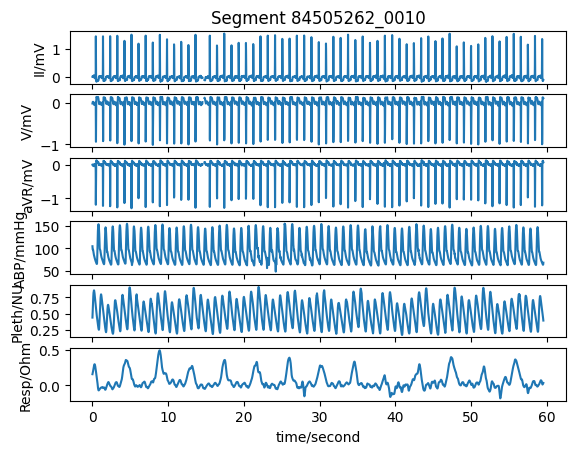

In [15]:
# Plot the extracted signals using the plot_wfdb function from the WFDB Toolbox.
title_text = f"Segment {rel_segment_name}"
wfdb.plot_wfdb(record=segment_data,
               title=title_text,
               time_units='seconds') 

#### Extract the PPG signal to loook at it more closely

Extracted the PPG signal from column 4 of the matrix of waveform data.


(-0.2, 1.5)

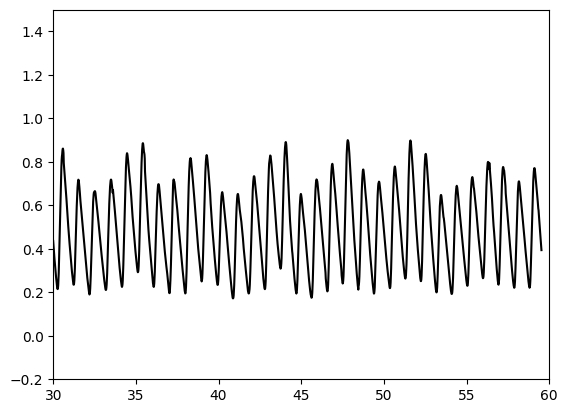

In [16]:
for sig_no in range(0, len(segment_data.sig_name)):
    if "Pleth" in segment_data.sig_name[sig_no]:
        break

ppg = segment_data.p_signal[:, sig_no]
fs = segment_data.fs
print(f"Extracted the PPG signal from column {sig_no} of the matrix of waveform data.")

# Plot to look at the shape of the PPG pulse wave more closely
from matplotlib import pyplot as plt
import numpy as np

t = np.arange(0, (len(ppg) / fs), 1.0 / fs)
plt.plot(t, ppg, color = 'black', label='PPG')
plt.xlim([30, 60])
plt.ylim([-0.2, 1.5])

#### Filter Signals

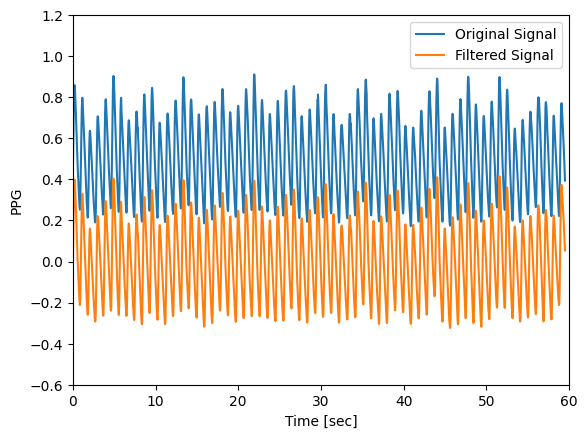

In [17]:
# Desired cutoff frequencies (in Hz).
lowcut = 0.1  # Example lower cut-off frequency
highcut = 10  # Example higher cut-off frequency

# Filter the signal
filtered_signal = filter_signal(ppg, lowcut, highcut, fs, order=6)

# Plot the original and filtered signals
plt.plot(t, ppg, label='Original Signal')
plt.plot(t, filtered_signal, label='Filtered Signal')
plt.xlabel('Time [sec]')
plt.ylabel('PPG')
plt.xlim([0, 60])
plt.ylim([-0.6, 1.2])
# plt.grid(True)
plt.legend()
plt.show()

#### Visulize time-frequency spectrogram

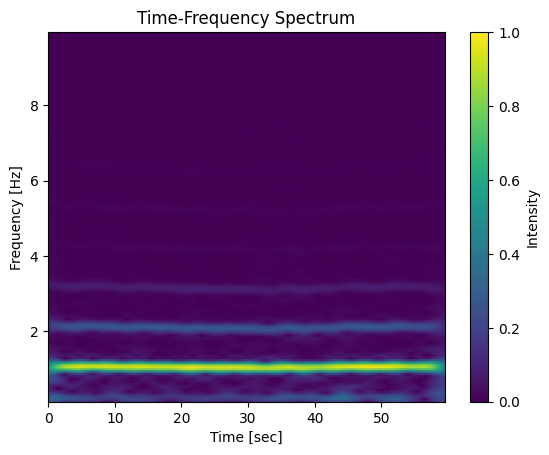

In [18]:
f, t, Zxx = stft(filtered_signal[:5000], fs=fs, window='hann', nperseg=512, noverlap=511, nfft=1024)
tfs = np.abs(Zxx)
# Only keep the frequecy values between lowcut and hightcut
f_idx =(f > lowcut) & (f < highcut)
tfs = tfs[f_idx, :]

# When preparing data for a neural network, it's common to either normalize or standardize the inputs
tfs = normalize(standardize(tfs))

plt.pcolormesh(t, f[f_idx], tfs, shading='gouraud')
plt.title('Time-Frequency Spectrum')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Intensity')
plt.show()

# Machine Learning with Physiological Waveforms

### Setup

In [19]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install torch-summary
!pip install seaborn

Looking in indexes: https://download.pytorch.org/whl/cu118



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


### Introduction to Convolutional Neural Networks (CNN)

#### What are Convolutional Neural Networks?
CNNs are a class of deep neural networks, most commonly applied to analyzing visual imagery. They are particularly known for their ability to capture spatial hierarchies in data, where higher-level patterns are composed of lower-level ones. 

A typical CNN has a series of layers: convolutional layers, pooling layers, fully connected layers, and normalization layers.

![What are CNN](https://editor.analyticsvidhya.com/uploads/25366Convolutional_Neural_Network_to_identify_the_image_of_a_bird.png)

#### How Do CNNs work?
The following are the key components of a CNN:
* **Convolutional Layers:** These layers use filters or kernels to perform convolution operations, capturing features like edges, textures, and other patterns in the image.
* **Activation Functions:** Functions like ReLU (Rectified Linear Unit) introduce non-linearities in the network, enabling it to learn complex patterns.
* **Pooling Layers:** Layers like Max Pooling are used to reduce dimensionality, thus reducing the computational complexity and overfitting risk.
* **Fully Connected Layers:** These layers, typically placed toward the end, are similar to traditional neural network layers and are used to flatten the output from convolutional and pooling layers for classification or regression tasks.
* **Normalization Layers:** Layers like Batch Normalization help in stabilizing and speeding up the training process.

![How Does CNN work](https://editor.analyticsvidhya.com/uploads/183560_qcMBDPuKpDvICcdd.png)

#### Applications of CNNs
* **Image and Video Recognition:** From identifying objects in photos to detecting actions in videos.
* **Medical Image Analysis:** Used for tumor detection, organ segmentation, and various other tasks in medical imaging.
* **Autonomous Vehicles:** For recognizing traffic signs, pedestrians, and other vehicles on the road.
* **Face Recognition:** Employed in security systems and photo tagging in social media.

We refer interested readers to [this page](https://www.analyticsvidhya.com/blog/2021/05/convolutional-neural-networks-cnn/) for additional information about CNNs and their broad applications.

## Building a CNN for Binary Classification

#### Implementing the CNN in Using PyTorch

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim


# Define the CNN Model
class SimpleBinaryCNN(nn.Module):
    def __init__(self):
        super(SimpleBinaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        # Leaky ReLU activation
        self.leaky_relu = nn.LeakyReLU(0.01)
        # Calculate the size of the flattened features after conv and pooling layers
        # Each pooling layer halves both dimensions
        final_dim_height = 162 // 2 // 2 // 2  # After 3 pooling layers
        final_dim_width = 310 // 2 // 2 // 2
        self.fc_input_size = 128 * final_dim_height * final_dim_width
        self.fc1 = nn.Linear(self.fc_input_size, 500)
        self.fc2 = nn.Linear(500, 1)

    def forward(self, x):
        x = self.pool(self.leaky_relu(self.conv1(x)))
        x = self.pool(self.leaky_relu(self.conv2(x)))
        x = self.pool(self.leaky_relu(self.conv3(x)))
        x = x.view(-1, self.fc_input_size)
        x = self.leaky_relu(self.fc1(x))
        x = self.fc2(x)
        return x

#### Visualizing the Architecture of the Model

In [21]:
from torchsummary import summary

# Assuming the inputs are 2D time-frequency spectrums of fixed size
input_shape = (162, 310)
model = SimpleBinaryCNN().float()
summary(model, (1, *input_shape))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 162, 310]        320
├─LeakyReLU: 1-2                         [-1, 32, 162, 310]        --
├─MaxPool2d: 1-3                         [-1, 32, 81, 155]         --
├─Conv2d: 1-4                            [-1, 64, 81, 155]         18,496
├─LeakyReLU: 1-5                         [-1, 64, 81, 155]         --
├─MaxPool2d: 1-6                         [-1, 64, 40, 77]          --
├─Conv2d: 1-7                            [-1, 128, 40, 77]         73,856
├─LeakyReLU: 1-8                         [-1, 128, 40, 77]         --
├─MaxPool2d: 1-9                         [-1, 128, 20, 38]         --
├─Linear: 1-10                           [-1, 500]                 48,640,500
├─LeakyReLU: 1-11                        [-1, 500]                 --
├─Linear: 1-12                           [-1, 1]                   501
Total params: 48,733,673
Trainable params: 48,733,673
Non-trainable

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 32, 162, 310]        320
├─LeakyReLU: 1-2                         [-1, 32, 162, 310]        --
├─MaxPool2d: 1-3                         [-1, 32, 81, 155]         --
├─Conv2d: 1-4                            [-1, 64, 81, 155]         18,496
├─LeakyReLU: 1-5                         [-1, 64, 81, 155]         --
├─MaxPool2d: 1-6                         [-1, 64, 40, 77]          --
├─Conv2d: 1-7                            [-1, 128, 40, 77]         73,856
├─LeakyReLU: 1-8                         [-1, 128, 40, 77]         --
├─MaxPool2d: 1-9                         [-1, 128, 20, 38]         --
├─Linear: 1-10                           [-1, 500]                 48,640,500
├─LeakyReLU: 1-11                        [-1, 500]                 --
├─Linear: 1-12                           [-1, 1]                   501
Total params: 48,733,673
Trainable params: 48,733,673
Non-trainable

## Training the CNN

#### Dataset Preparation and Handling

In [22]:
from torch.utils.data import DataLoader, TensorDataset, random_split

# Data Preparation 
# Open the pickle file in 'read binary' mode
with open('dataset.pkl', 'rb') as file:
    data = pickle.load(file)
# Now 'data' holds the content of the pickle file
X = data["X"]
Y = data["Y"]
X = torch.tensor(np.stack(X).astype(np.float64)).unsqueeze(1)
Y = torch.tensor(np.stack(Y).astype(np.float64))
X, Y = torch.nan_to_num(X), torch.nan_to_num(Y) 

# Create DataLoader for training and testing
num_samples = len(Y)
dataset = TensorDataset(X, Y)
train_size = int(0.8 * num_samples)
test_size = num_samples - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

#### Implementing the Training Loop
> **📌 Note:** This may take several minutes.

In [23]:
# Create the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleBinaryCNN().double().to(device)

# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training the Model
num_epochs = 1
for epoch in range(num_epochs):
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{num_epochs}], Step [{i + 1}/{len(train_loader)}], Loss: {loss.item():.4f}')

# Save the model
torch.save(model.state_dict(), 'binary_classification_model.pth')
print("Save the trained model: binary_classification_model.pth")

Epoch [1/1], Step [10/66], Loss: 0.7099
Epoch [1/1], Step [20/66], Loss: 0.6861
Epoch [1/1], Step [30/66], Loss: 0.6450
Epoch [1/1], Step [40/66], Loss: 0.6613
Epoch [1/1], Step [50/66], Loss: 0.6081
Epoch [1/1], Step [60/66], Loss: 0.6121
Save the trained model: binary_classification_model.pth


## Evaluating the Model

#### Performance Metrics (Accuracy, Precision, Recall, F1-score)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Testing the Model
predicted_labels, ground_truth = [], []           
model.eval()
model.double()
with torch.no_grad():
    correct = 0
    total = 0
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = torch.sigmoid(outputs).round()  # Using sigmoid to convert logits to probabilities
        predicted_labels.append(predicted[0])
        ground_truth.append(labels[0])

# Calculate metrics
accuracy = accuracy_score(ground_truth, predicted_labels)
precision = precision_score(ground_truth, predicted_labels)
recall = recall_score(ground_truth, predicted_labels)
f1 = f1_score(ground_truth, predicted_labels)

print("Prformance metrics of the model on the test set:")
print(f"Accuracy: {round(accuracy, 2)}")
print(f"Precision: {round(precision, 2)}")
print(f"Recall: {round(recall, 2)}")
print(f"F1 Score: {round(f1, 2)}")

Prformance metrics of the model on the test set:
Accuracy: 0.76
Precision: 0.88
Recall: 0.7
F1 Score: 0.78


#### Confusion Matrix

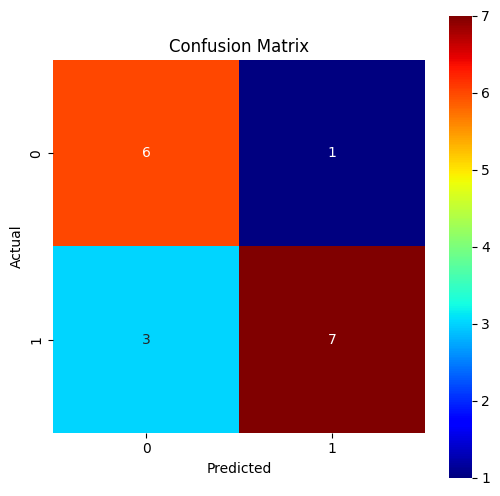

In [25]:
import seaborn as sns
from sklearn.metrics import confusion_matrix


# Calculate the confusion matrix
cm = confusion_matrix(ground_truth, predicted_labels)

# Plot the confusion matrix using Seaborn
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap='jet', square=True, xticklabels=[0, 1], yticklabels=[0, 1])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

#### ROC and ROC-AUC Analysis

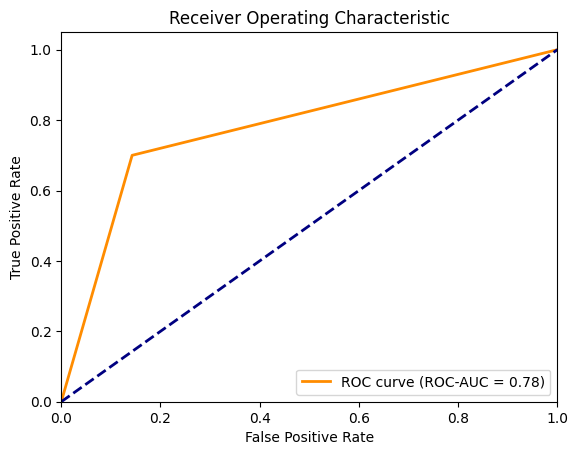

In [26]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(ground_truth, predicted_labels)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (ROC-AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#### PRC and PR-AUC Analysis

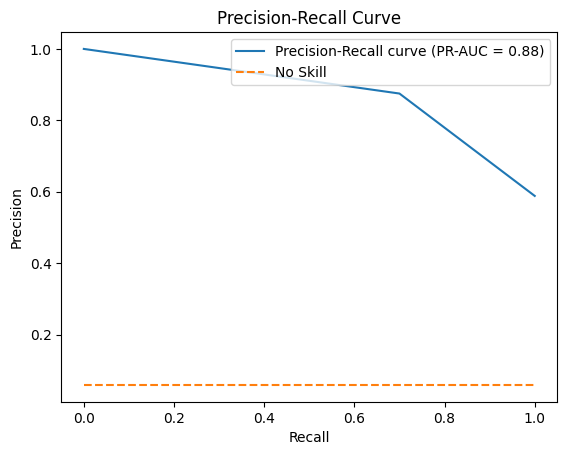

In [27]:
from sklearn.metrics import precision_recall_curve

# Calculate PRC curve and PRAUC
precision, recall, thresholds = precision_recall_curve(ground_truth, predicted_labels)
pr_auc = auc(recall, precision)

# Plot the ROC curve
plt.figure()
plt.plot(recall, precision, label=f'Precision-Recall curve (PR-AUC = {pr_auc:.2f})')

no_skill = len(ground_truth[ground_truth==1]) / len(ground_truth)
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.show()

##  Model Prediction

#### Predict hospital mortality in ICU by giving an input (PPG time-frequency spectrum)

In [28]:
def load_model(model_path):
    model = SimpleBinaryCNN().double()
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model

def predict(model, input_tensor):
    with torch.no_grad():
        output = model(input_tensor)
        prediction = torch.sigmoid(output).round().item()
        return prediction

# Load the trained model
model = load_model('binary_classification_model.pth')

# Create a dummy input tensor for inference (example)
input_tensor = torch.randn(1, *input_shape, dtype=torch.double)

# Get prediction
prediction = predict(model, input_tensor)
print(f"Predicted class/hospital_expire_flag = {prediction}")

Predicted class/hospital_expire_flag = 0.0
